
# 📊 Data Wrangling Exercise: Health App Logs

**Objective:**  
Clean, analyze, visualize, and interpret Health App log data step by step.

> Upload `HealthApp_2k.log` to the same directory before running this notebook.



## Part 1: Data Ingestion & String Manipulation


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load raw log file
log_file = "HealthApp_2k.log"

with open(log_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

df_raw = pd.DataFrame(lines, columns=["raw_text"])

df_raw.head()


,raw_text
0,20171223-22:15:29:606|Step_LSC|30002312|onStan...
1,20171223-22:15:29:615|Step_LSC|30002312|onExte...
2,20171223-22:15:29:633|Step_StandReportReceiver...
3,20171223-22:15:29:635|Step_LSC|30002312|proces...
4,20171223-22:15:29:635|Step_StandStepCounter|30...



### Split raw text into structured columns


In [11]:
df = df_raw["raw_text"].str.split("|", n=3, expand=True)

df.columns = ["Time", "Component", "PID", "Content"]

df.head()

,Time,Component,PID,Content
0,20171223-22:15:29:606,Step_LSC,30002312,onStandStepChanged 3579\n
1,20171223-22:15:29:615,Step_LSC,30002312,onExtend:1514038530000 14 0 4\n
2,20171223-22:15:29:633,Step_StandReportReceiver,30002312,onReceive action: android.intent.action.SCREEN...
3,20171223-22:15:29:635,Step_LSC,30002312,processHandleBroadcastAction action:android.in...
4,20171223-22:15:29:635,Step_StandStepCounter,30002312,flush sensor data\n



### Convert Time column to datetime and set as index


In [12]:

df["Time"] = pd.to_datetime(df["Time"], format="%Y%m%d-%H:%M:%S:%f")
df.set_index("Time", inplace=True)
df.head()


,Component,PID,Content
Time,,,
2017-12-23 22:15:29.606,Step_LSC,30002312,onStandStepChanged 3579\n
2017-12-23 22:15:29.615,Step_LSC,30002312,onExtend:1514038530000 14 0 4\n
2017-12-23 22:15:29.633,Step_StandReportReceiver,30002312,onReceive action: android.intent.action.SCREEN...
2017-12-23 22:15:29.635,Step_LSC,30002312,processHandleBroadcastAction action:android.in...
2017-12-23 22:15:29.635,Step_StandStepCounter,30002312,flush sensor data\n



## Part 2: Data Extraction


In [13]:

# Top 5 components by frequency
df["Component"].value_counts().head(5)


Component
Step_LSC                    710
Step_SPUtils                494
Step_ExtSDM                 482
Step_StandReportReceiver    171
HiH_HiSyncControl            42
Name: count, dtype: int64


### Filter REPORT logs


In [14]:

report_df = df[df["Content"].str.contains("REPORT", na=False)].copy()
report_df.head()


,Component,PID,Content
Time,,,
2017-12-23 22:15:29.649,Step_StandReportReceiver,30002312,REPORT : 7007 5002 150089 240\n
2017-12-23 22:15:29.962,Step_StandReportReceiver,30002312,REPORT : 7008 5003 150111 240\n
2017-12-23 22:15:30.642,Step_StandReportReceiver,30002312,REPORT : 7009 5004 150132 240\n
2017-12-23 22:15:31.160,Step_StandReportReceiver,30002312,REPORT : 7011 5005 150175 240\n
2017-12-23 22:15:32.163,Step_StandReportReceiver,30002312,REPORT : 7012 5006 150197 240\n



### Parse REPORT metrics


In [15]:

metrics = report_df["Content"].str.extract(r"REPORT : (\d+) (\d+) (\d+) (\d+)")
metrics.columns = ["StepCount", "Distance", "Calories", "Altitude"]

report_df = report_df.join(metrics)
report_df[["StepCount", "Distance", "Calories", "Altitude"]] = report_df[["StepCount", "Distance", "Calories", "Altitude"]].astype(int)

# Convert Calories to Kcal
report_df["Kcal"] = report_df["Calories"] / 1000
report_df.head()


,Component,PID,Content,StepCount,Distance,Calories,Altitude,Kcal
Time,,,,,,,,
2017-12-23 22:15:29.649,Step_StandReportReceiver,30002312,REPORT : 7007 5002 150089 240\n,7007,5002,150089,240,150.089
2017-12-23 22:15:29.962,Step_StandReportReceiver,30002312,REPORT : 7008 5003 150111 240\n,7008,5003,150111,240,150.111
2017-12-23 22:15:30.642,Step_StandReportReceiver,30002312,REPORT : 7009 5004 150132 240\n,7009,5004,150132,240,150.132
2017-12-23 22:15:31.160,Step_StandReportReceiver,30002312,REPORT : 7011 5005 150175 240\n,7011,5005,150175,240,150.175
2017-12-23 22:15:32.163,Step_StandReportReceiver,30002312,REPORT : 7012 5006 150197 240\n,7012,5006,150197,240,150.197



## Part 3: Exploratory Data Analysis


In [16]:

report_df[["StepCount", "Kcal"]].describe()


,StepCount,Kcal
count,136.000000,136.000000
mean,7054.264706,151.101868
std,613.073619,13.131998
min,0.000000,0.000000
25%,7040.750000,150.812500
50%,7100.000000,152.081500
75%,7183.500000,153.869750
max,7214.000000,154.523000



### Midnight reset detection


In [17]:

report_df[report_df["StepCount"] == 0].head()


,Component,PID,Content,StepCount,Distance,Calories,Altitude,Kcal
Time,,,,,,,,
2017-12-24 00:00:00.236,Step_StandReportReceiver,30002312,REPORT : 0 0 0 0\n,0,0,0,0,0.0



## Part 4: Time Series Analysis


In [19]:

# Resample to 1-minute intervals
minute_df = report_df.resample("1min").max()

# Steps per minute
minute_df["Steps_Per_Minute"] = minute_df["StepCount"].diff()
minute_df.head()


,Component,PID,Content,StepCount,Distance,Calories,Altitude,Kcal,Steps_Per_Minute
Time,,,,,,,,,
2017-12-23 22:15:00,Step_StandReportReceiver,30002312,REPORT : 7053 5035 151075 240\n,7053.0,5035.0,151075.0,240.0,151.075,NaN
2017-12-23 22:16:00,Step_StandReportReceiver,30002312,REPORT : 7054 5036 151096 240\n,7054.0,5036.0,151096.0,240.0,151.096,1.0
2017-12-23 22:17:00,Step_StandReportReceiver,30002312,REPORT : 7109 5075 152274 240\n,7109.0,5075.0,152274.0,240.0,152.274,55.0
2017-12-23 22:18:00,Step_StandReportReceiver,30002312,REPORT : 7114 5079 152381 240\n,7114.0,5079.0,152381.0,240.0,152.381,5.0
2017-12-23 22:19:00,Step_StandReportReceiver,30002312,REPORT : 7167 5117 153517 240\n,7167.0,5117.0,153517.0,240.0,153.517,53.0



### Peak activity time


In [20]:

minute_df["Steps_Per_Minute"].idxmax(), minute_df["Steps_Per_Minute"].max()


(Timestamp('2017-12-23 22:17:00'), np.float64(55.0))


## Part 5: Visualization


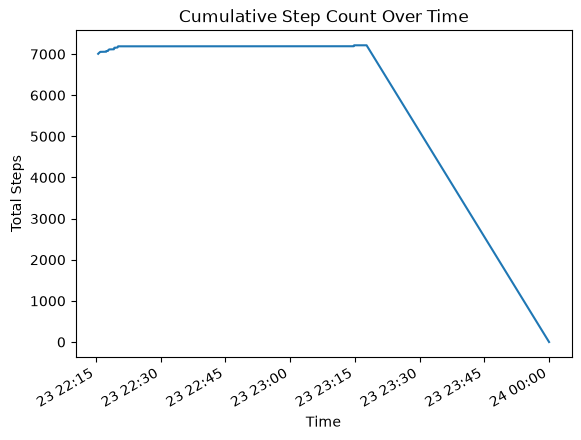

In [ ]:

# Step progression
plt.figure()
report_df["StepCount"].plot()
plt.xlabel("Time")
plt.ylabel("Total Steps")
plt.title("Cumulative Step Count Over Time")
plt.savefig("images/step_count.png", dpi=300, bbox_inches="tight")
plt.show()


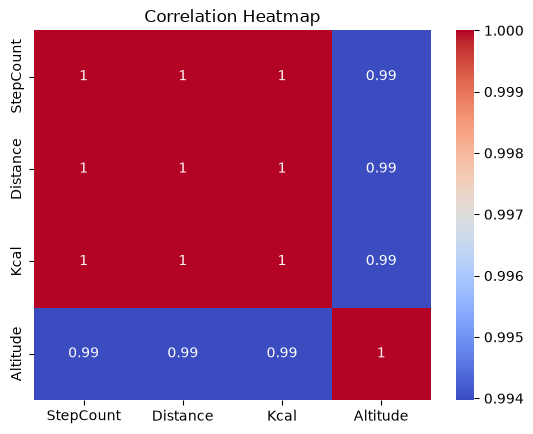

In [ ]:

# Correlation heatmap
corr = report_df[["StepCount", "Distance", "Kcal", "Altitude"]].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


The HealthApp logs show that the user maintained steady physical activity during the recorded session, with the step count gradually increasing from around 7,000 to over 7,200 steps. Minute-wise analysis indicates that activity occurred consistently, with the highest increase reaching about 55 steps in a single minute. Calories burned also increased steadily in proportion to the user's movement, while altitude remained nearly constant, suggesting the activity took place on mostly level ground. Overall, the logs indicate normal walking behavior with no major interruptions or unusual sensor readings.